[*********************100%***********************]  3 of 3 completed


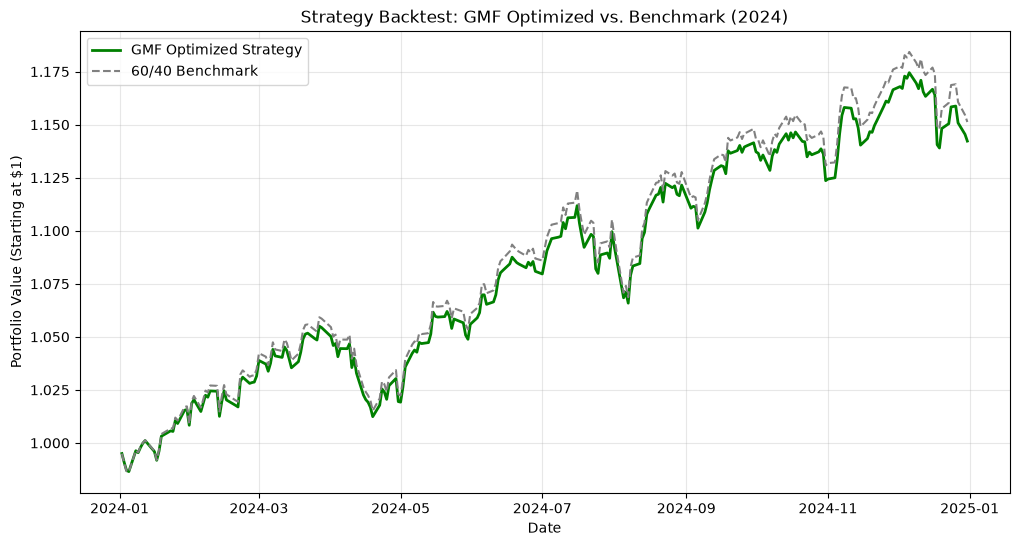

Final Strategy Return: 14.23%
Final Benchmark Return: 15.12%
Strategy Volatility: 7.79%
Benchmark Volatility: 8.16%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Fetch data again for returns calculation
assets = ['TSLA', 'BND', 'SPY']
data = yf.download(assets, start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
returns = data.pct_change().dropna()

# 2. Define our Backtest Period (The last year: 2024)
backtest_returns = returns.loc['2024-01-01':'2024-12-31']

# 3. Define Portfolio Weights
# Our Strategy (from Task 4)
strat_weights = np.array([0.43787, 0.56213, 0.0]) # BND, SPY, TSLA

# Benchmark (Standard 60/40 Portfolio)
bench_weights = np.array([0.40, 0.60, 0.0])

# 4. Calculate Daily Returns for both
# Note: Ensure the order of weights matches the columns in 'backtest_returns'
# Use backtest_returns.columns to check the order (usually alphabetical: BND, SPY, TSLA)
strat_daily_ret = (backtest_returns * strat_weights).sum(axis=1)
bench_daily_ret = (backtest_returns * bench_weights).sum(axis=1)

# 5. Calculate Cumulative Returns (Growth of $1)
strat_cum_ret = (1 + strat_daily_ret).cumprod()
bench_cum_ret = (1 + bench_daily_ret).cumprod()

# 6. Plot the Performance Comparison
plt.figure(figsize=(12,6))
plt.plot(strat_cum_ret, label='GMF Optimized Strategy', color='green', linewidth=2)
plt.plot(bench_cum_ret, label='60/40 Benchmark', color='gray', linestyle='--')
plt.title('Strategy Backtest: GMF Optimized vs. Benchmark (2024)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Starting at $1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Final Metrics
final_strat_return = (strat_cum_ret.iloc[-1] - 1) * 100
final_bench_return = (bench_cum_ret.iloc[-1] - 1) * 100

print(f"Final Strategy Return: {final_strat_return:.2f}%")
print(f"Final Benchmark Return: {final_bench_return:.2f}%")

# Calculate Annualized Volatility for both
strat_vol = strat_daily_ret.std() * np.sqrt(252) * 100
bench_vol = bench_daily_ret.std() * np.sqrt(252) * 100

print(f"Strategy Volatility: {strat_vol:.2f}%")
print(f"Benchmark Volatility: {bench_vol:.2f}%")